In [22]:
import os
import glob
from typing import Dict, List, Tuple, Optional

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from pcmdi_enso_reader import (
    ENSODiagReader
)

In [28]:
class ENSODiagPlotter:
    """
    Plot ENSO amplitude diagnostics (e.g., SSTA std vs longitude)
    using a data_dict that contains:
      - 'reference': obs DataArray
      - 'hist', 'future', ... : model DataArrays (member/sample, longitude)
    """

    def __init__(
        self,
        data_dict: dict,
        fig_dir: str,
        plot_dict: dict,
        group_order=("hist", "future"),
        obs_key: str = "reference",
    ):
        """
        Parameters
        ----------
        data_dict : dict
            {
              'reference': obs DataArray,
              'hist':      model DataArray,
              'future':    model DataArray,
              ...
            }
        fig_dir : str
            Directory where figures are saved.
        plot_dict : dict
            Styling and labels for each key in data_dict, e.g.
              {
                "reference": {"label": "...", "color": "black",   "alpha": 0.55},
                "hist":      {"label": "...", "color": "steelblue","alpha": 0.55},
                "future":    {"label": "...", "color": "tomato",  "alpha": 0.55},
              }
        group_order : sequence
            Order of model groups to plot and to stack into the 'period' dim.
        obs_key : str
            Key in data_dict / plot_dict for observations.
        """
        self.data_dict   = data_dict
        self.fig_dir     = fig_dir
        self.plot_dict   = plot_dict
        self.group_order = tuple(group_order)
        self.obs_key     = obs_key

        # Build ds_amp (metric with dims: period, member, longitude) and obs_da
        self.ds_amp, self.obs_da = self._build_amp_and_obs()

    def _build_amp_and_obs(self) -> tuple[xr.Dataset, xr.DataArray]:
        """Build ds_amp['metric'] and obs_da from data_dict."""
        # ---- observation ----
        if self.obs_key not in self.data_dict:
            raise ValueError(f"data_dict must contain obs_key='{self.obs_key}'")

        obs_da = self.data_dict[self.obs_key]
        if "longitude" in obs_da.dims:
            extra = [d for d in obs_da.dims if d != "longitude"]
            if extra:
                obs_da = obs_da.mean(dim=extra)

        # ---- model fields → metric(period, member, longitude) ----
        amp_list = []
        for group in self.group_order:
            if group not in self.data_dict:
                raise ValueError(
                    f"Expected group '{group}' in data_dict, found keys: {list(self.data_dict.keys())}"
                )
            da_g = self.data_dict[group]

            # ensure there is a 'member' dim
            if "member" not in da_g.dims:
                if "sample" in da_g.dims:
                    da_g = da_g.rename({"sample": "member"})
                elif len(da_g.dims) == 2 and "longitude" in da_g.dims:
                    # heuristic: the other dim is member-like
                    other = [d for d in da_g.dims if d != "longitude"][0]
                    da_g = da_g.rename({other: "member"})

            # average any extra dims beyond (member, longitude)
            extra_dims = [d for d in da_g.dims if d not in ("member", "longitude")]
            if extra_dims:
                da_g = da_g.mean(dim=extra_dims)

            # add a period coord with value = group name
            da_g = da_g.expand_dims(period=[group])
            amp_list.append(da_g)

        metric = xr.concat(amp_list, dim="period")  # (period, member, longitude)
        ds_amp = metric.to_dataset(name="metric")
        return ds_amp, obs_da

    def _prep_amp(self) -> xr.DataArray:
        """
        Return amplitude DataArray from ds_amp['metric'].
        Dims: (period, member, longitude)
        """
        da = self.ds_amp["metric"]
        extra_dims = [d for d in da.dims if d not in ("period", "member", "longitude")]
        if extra_dims:
            da = da.mean(dim=extra_dims)
        return da
        
    @staticmethod
    def _format_lon(lon):
        """
        Convert longitude in degrees to string label.
        Assumes lon in [0, 360]; adjust if needed.
        """
        lon = float(lon)
        if lon == 0 or lon == 360:
            return "0°"
        if lon == 180:
            return "180°"
        if lon < 180:
            return f"{int(lon)}°E"
        else:
            return f"{int(360 - lon)}°W"
            
    def plot_var_lon(
        self,
        filename: str = "enso_amplitude_hist_future_ens.pdf",
        ymin: Optional[float] = None,
        ymax: Optional[float] = None,
        show_spread: bool = True,
        title: str = "ENSO amplitude (SSTA standard deviation)",
        xlabel: str = "longitude",
        ylabel: str = r"SSTA std ($^\circ$C)",
        xint: int = 30, 
        figsize: tuple = (5, 4),
        fontz: int = 12,
        fig_dpi: int = 150,
        fig_format: str = "png",
    ):
        da  = self._prep_amp()               # (period, member, longitude)
        lon = da["longitude"].values
    
        fig = plt.figure(figsize=figsize)
        # Force fixed subplot geometry (critical for combined layout)
        gs = fig.add_gridspec(
            1, 1,
            left=0.18,    # margin left
            right=0.97,   # margin right
            bottom=0.16,  # margin bottom
            top=0.90      # margin top
        )
        
        ax = fig.add_subplot(gs[0, 0])

        # --- font sizes ---
        ax.set_xlabel(xlabel, fontsize=fontz * 1.0)
        ax.set_ylabel(ylabel, fontsize=fontz * 1.0)
        ax.set_title(title,  fontsize=fontz * 1.1, loc="left")
        ax.tick_params(
            axis="both", 
            length=8,         # tick length (points)
            width=0.8,        # tick line width
            direction="out",  # or "in", "inout"
            labelsize=fontz * 0.95
        )

        
        # --- observations (from data_dict[obs_key]) ---
        if self.obs_da is not None:
            obs = self.obs_da
            if "longitude" in obs.dims:
                obs_vals = obs.sel(longitude=lon, method="nearest")
            else:
                obs_vals = obs

            obs_style = self.plot_dict.get(self.obs_key, {})
            obs_label = obs_style.get("label", "Reference")
            obs_color = obs_style.get("color", "black")

            ax.plot(
                lon,
                obs_vals,
                linewidth=2,
                color=obs_color,
                label=obs_label,
            )
    
        # --- ensemble curves for each period/group ---
        for pval in da["period"].values:
            key = str(pval)   # e.g. "hist", "future"
            style = self.plot_dict.get(key, {})
            label = style.get("label", key)
            color = style.get("color", None)
            alpha_fill = style.get("alpha", 0.2)

            da_p   = da.sel(period=pval)   # (member, longitude)
            mean_p = da_p.mean("member")
            std_p  = da_p.std("member")
    
            line = ax.plot(
                lon, mean_p,
                linewidth=2,
                label=label,
                color=color,
            )[0]
            if color is None:
                color = line.get_color()
    
            if show_spread:
                ax.fill_between(
                    lon, mean_p - std_p, mean_p + std_p,
                    color=color, alpha=alpha_fill, linewidth=0,
                )
    
        # --- longitude ticks / labels ---
        lon_min = float(lon.min())
        lon_max = float(lon.max())
        lon_min_rounded = np.floor(lon_min / xint) * xint
        lon_max_rounded = np.ceil(lon_max / xint) * xint
        xticks = np.arange(lon_min_rounded, lon_max_rounded + 1e-6, xint)
    
        ax.set_xticks(xticks)
        ax.set_xticklabels(
            [self._format_lon(x) for x in xticks],
            fontsize=fontz * 0.95,
        )
    
        if ymin is not None or ymax is not None:
            ax.set_ylim(ymin, ymax)
            
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="best", frameon=True, fontsize=fontz * 0.9)
    
        out_path = os.path.join(self.fig_dir, filename)
        
        fig.subplots_adjust(
            left=0.22, right=0.97, bottom=0.16, top=0.90
        )
        
        fig.savefig(
            out_path, 
            dpi=fig_dpi, 
            format=fig_format, 
            bbox_inches="tight", 
            pad_inches=0.05
        )
        
        print(f"Saved ENSO amplitude diagnostic figure to {out_path}")
        return fig, ax


Available ENSO groups: ['ENSO_perf', 'ENSO_proc', 'ENSO_tel']
Variables in ENSO_perf: ['pr_lat_rmse', 'pr_lon_rmse', 'sst_lon_rmse', 'taux_lon_rmse', 'enso_amplitude', 'enso_duration', 'enso_seasonality', 'enso_sst_diversity_mode1', 'enso_sst_diversity_mode2', 'enso_sst_lon_rmse', 'enso_sst_skewness', 'enso_sst_ts_rmse', 'seasonal_pr_lat_rmse', 'seasonal_pr_lon_rmse', 'seasonal_sst_lon_rmse', 'seasonal_taux_lon_rmse']

>>> Loading target_var = sstStd_lon
processing period: hist
processing period: future
  Group: hist
  Group: future

✓ All target_var successfully read.

Variable: sstStd_lon
  Group: reference
type=DataArray | shape=(120,) | dims=('longitude',)
  Group: hist
type=DataArray | shape=(25, 120) | dims=('member', 'longitude')
  Group: future
type=DataArray | shape=(25, 120) | dims=('member', 'longitude')
Saved ENSO amplitude diagnostic figure to ./enso_enso_amplitude_hist_future_ens.pdf
Available ENSO groups: ['ENSO_perf', 'ENSO_proc', 'ENSO_tel']
Variables in ENSO_perf: ['p

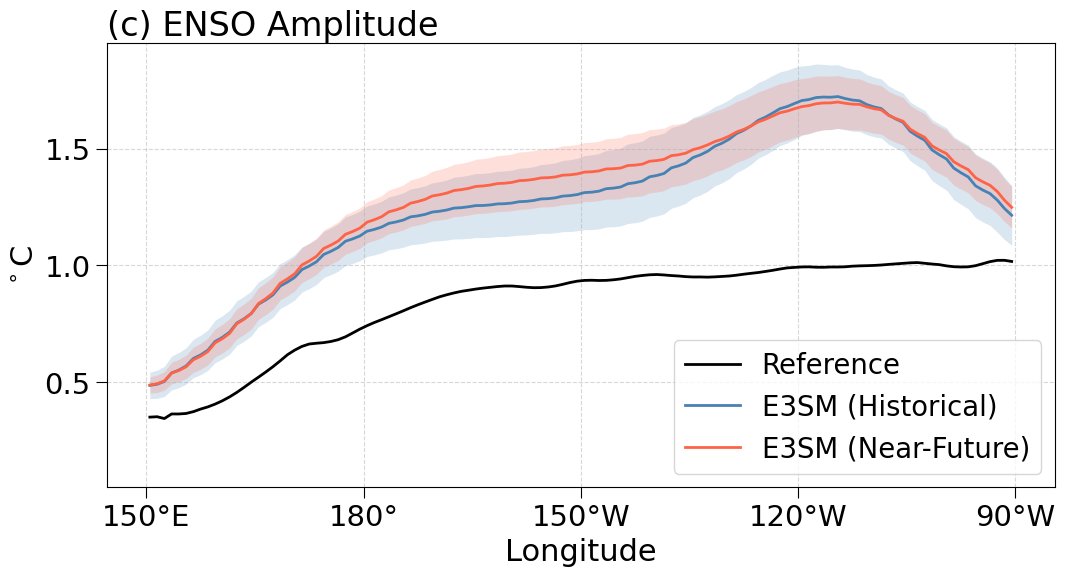

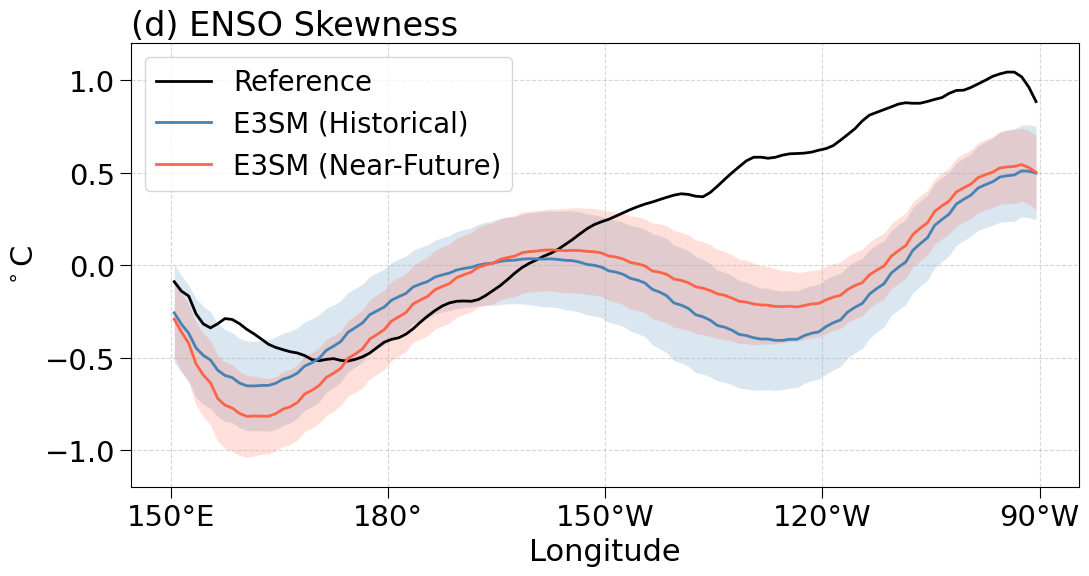

In [30]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"
    FIG_DIR   = "./"
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    # ---- Pair experiments consistently (order matters) ----
    MODEL   = "v3.LR.historical"
    GROUP   = ["hist", "future"]
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]

    members = None
    verbose = False
    diag_print = True 
    fig_idx_start = 2 
    
    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=GROUP,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )

    target_metric_dict = {
        "enso_amplitude" : {
            "vars": ["sstStd_lon"],
            "obs" : {"hist": "ERA-Interim","future": "ERA-Interim2"},
            "group": "ENSO_perf",
            "label" : "ENSO Amplitude",
            "unit" : r"$^\circ$C",
            "ymin" : 0.05,
            "ymax" : 1.95,
            "rtol" : 1e-2
        },
        "enso_sst_skewness" : {
            "vars": ["sstSke_lon"], #,"reg_taux_over_POSsst_lon","reg_taux_over_NEGsst_lon"],
            "obs" : {"hist": "ERA-Interim","future": "ERA-Interim2"},
            "group": "ENSO_perf",
            "label" : "ENSO Skewness",
            "unit" : r"$^\circ$C",
            "ymin" : -1.2,
            "ymax" : 1.2, 
            "rtol" : 1e-2
        },
    }
    
    pool_members_to_samples = False

    for i,target_metric in enumerate(target_metric_dict.keys()):
        target_var_list = target_metric_dict[target_metric]['vars']
        target_obs_dict = target_metric_dict[target_metric]['obs'] 
        target_group = target_metric_dict[target_metric]['group']  
        target_rtol = target_metric_dict[target_metric]['rtol']
        target_ymin = target_metric_dict[target_metric]['ymin']
        target_ymax = target_metric_dict[target_metric]['ymax']
        target_label = target_metric_dict[target_metric]['label']
        target_unit = target_metric_dict[target_metric]['unit']
        
        # ---- Sanity checks ----
        print("Available ENSO groups:", reader.available_groups())
        print(f"Variables in {target_group}:", reader.available_vars(target_group))
    
        if target_group not in reader.available_groups():
            raise ValueError(f"Unknown target_group: {target_group}")
    
        if target_metric not in reader.available_vars(target_group):
            raise ValueError(f"Unknown target_metric '{target_metric}' for '{target_group}'")
    
        # ----------------------------------------------------
        # Loop through target variable list
        # ----------------------------------------------------
        for j,target_var in enumerate(target_var_list):
            print(f"\n>>> Loading target_var = {target_var}")
            data_dict = {} 
            
            # Load model + obs using your working function
            dm, do = reader.load_metric_data(
                enso_group=target_group,
                var_name=target_metric,
                nc_var=target_var,
                ref_dict=target_obs_dict,
            )
    
            # observation only has one member and is identical for historical and near-future
            #print(do["hist"]["00"].values)
            #print(do["future"]["00"].values)
    
            ref = reader.validate_constant_observation(
                do, ref_group="hist", ref_member="00", sample_dim=None,
                use_allclose=True,rtol=target_rtol, atol=0.0,
                pool_ensemble = pool_members_to_samples, 
            )
            
            # If we get here, all obs are identical
            # ref is the DataArray you want to keep
            data_dict['reference'] = ref
            
            for group, member_dict in dm.items():
                print(f"  Group: {group}")
                pooled = reader.combine_members_to_array(member_dict, sample_dim=None)  
                data_dict[group] = pooled
                
            print("\n✓ All target_var successfully read.")
        
            if diag_print: 
                print(f"\nVariable: {target_var}")
                for group, da in data_dict.items():
                    print(f"  Group: {group}")
                    # da is an xarray DataArray or Dataset
                    shape = getattr(da, "shape", None)
                    dims  = getattr(da, "dims", None)
                    print(f"type={type(da).__name__} | shape={shape} | dims={dims}")
                    
            plot_dict = {        
                "reference": {
                    "label": "Reference", #f"{target_obs_dict['hist'].replace("_"," .vs. ")} (Reference)",
                    "color": "black",
                    "alpha": 0.2,
                },
                "hist": {
                    "label": "E3SM (Historical)",
                    "color": "steelblue",
                    "alpha": 0.2,
                },
                "future": {
                    "label": "E3SM (Near-Future)",
                    "color": "tomato",
                    "alpha": 0.2,
                },
            }
            
            var_label_map = {
                "sstStd_lon": "SSTA standard deviation",
            }
            
            label_base  = var_label_map.get(target_var, target_var)
            figure_name = f"enso_{target_metric}_hist_future_ens.pdf"
            ymin        = None
            ymax        = None
            show_spread = True
            title       =  f"({chr(j + i*len(target_var_list) + fig_idx_start  + 97)}) {target_label}"  
            xlabel      = "Longitude"
            ylabel      = rf"{target_unit}"
            fontz       = 22
            figure_size = (12, 6)
            fig_dpi     = 300
            fig_format  = "pdf"
            
            plotter = ENSODiagPlotter(
                data_dict=data_dict,
                fig_dir=FIG_DIR,
                plot_dict=plot_dict,
                group_order=GROUP,      # ["hist", "future"]
                obs_key="reference",
            )
            
            plotter.plot_var_lon(
                filename=figure_name,
                ymin=target_ymin,
                ymax=target_ymax,
                title=title,
                xlabel=xlabel,
                ylabel=ylabel,
                fontz=fontz,
                figsize=figure_size,
                show_spread=show_spread,
                fig_dpi=fig_dpi,
                fig_format=fig_format
            )
